# Regime Detection and Adaptive Trading 📈📊💱
 **Proyecto:** Detección de Régimen y Trading Adaptativo  

 **Autor:** Francisco Encina  

 **Profesor:** Nicolás Torres

 **Curso:** Aprendizaje de Máquinas - IPD440

 **Universidad Técnica Federico Santa María**

---

## 📋 Estructura del Proyecto

1. **Data Extraction & Feature Engineering**
2. **Regime Detection (HMM)**
3. **ML Models por Régimen**
4. **Trading Strategy & Backtesting**

*This notebook contains: ML Models por Régimen*

*Objetivo: Entrenar modelos ML especializados para cada régimen de mercado*

*Hipótesis clave: Un modelo entrenado específicamente en datos de "Bull Market" será mejor prediciendo en ese contexto que un modelo genérico entrenado en todos los datos.*

In [ ]:
# Instalar dependencias
!pip install xgboost scikit-learn shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 1.2 MB/s eta 0:00:00


In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ML
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

In [ ]:
# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 3.1 Cargar Datos con Regímenes

In [ ]:
# Cargar datos del Step 2
df = pd.read_csv('data_with_regimes.csv', index_col=0, parse_dates=True)

print(f"✓ Datos cargados: {len(df)} días")
print(f"  Rango: {df.index[0].date()} → {df.index[-1].date()}")

# Preview
print("\n📊 Preview:")
print(df[['Adj Close', 'Returns', 'Volatility_20', 'Regime', 'Regime_Name']].tail())

# Distribución de regímenes
print("\n📊 Distribución de regímenes:")
print(df['Regime_Name'].value_counts())

✓ Datos cargados: 8086 días
  Rango: 1993-11-11 → 2025-12-26

📊 Preview:
             Adj Close   Returns  Volatility_20  Regime  Regime_Name
Date                                                                
2025-12-19  680.590027  0.009063       0.107004     0.0  Bull Market
2025-12-22  684.830017  0.006230       0.104234     0.0  Bull Market
2025-12-23  687.960022  0.004570       0.093611     0.0  Bull Market
2025-12-24  690.380005  0.003518       0.089319     0.0  Bull Market
2025-12-26  690.309998 -0.000101       0.086907     0.0  Bull Market

📊 Distribución de regímenes:
Regime_Name
Bear Market        3280
Bull Market        3269
High Volatility    1537
Name: count, dtype: int64


## 3.2 Feature Engineering para ML

Vamos a crear features predictivos que capturen:
 - Momentum a diferentes escalas
 - Volatilidad histórica
 - Indicadores técnicos
 - Relaciones entre precio y medias móviles

In [ ]:
def create_ml_features(df):
    """
    Crea features adicionales específicos para ML
    """
    data = df.copy()

    print("🔧 Creando features para ML...")

    # Ya tenemos muchos features del Step 1, agregaremos algunos extras

    # ==================
    # LAGGED FEATURES (valores pasados)
    # ==================
    for lag in [1, 2, 3, 5]:
        data[f'Returns_lag_{lag}'] = data['Returns'].shift(lag)
        data[f'Volatility_lag_{lag}'] = data['Volatility_20'].shift(lag)

    # ==================
    # MOVING AVERAGE CROSSOVERS
    # ==================
    data['SMA_20_50_cross'] = (data['SMA_20'] / data['SMA_50']) - 1
    data['SMA_50_200_cross'] = (data['SMA_50'] / data['SMA_200']) - 1

    # ==================
    # VOLATILITY RATIOS (cambios en volatilidad)
    # ==================
    data['Vol_5_20_ratio'] = data['Volatility_5'] / data['Volatility_20']
    data['Vol_change'] = data['Volatility_20'].pct_change()

    # ==================
    # PRICE MOMENTUM INDICATORS
    # ==================
    data['ROC_5'] = data['Adj Close'].pct_change(5)   # Rate of Change
    data['ROC_10'] = data['Adj Close'].pct_change(10)

    # ==================
    # VOLUME INDICATORS
    # ==================
    data['Volume_change'] = data['Volume'].pct_change()

    # ==================
    # TARGET: Predecir dirección del mercado (siguiente día)
    # ==================
    # 1 = Up (retorno positivo mañana), 0 = Down (retorno negativo mañana)
    data['Target'] = (data['Returns'].shift(-1) > 0).astype(int)

    # Drop NaNs
    data = data.dropna()

    print(f"✓ Features ML creados")
    print(f"  Total columnas: {len(data.columns)}")
    print(f"  Filas válidas: {len(data)}")

    return data

# Crear features
df_ml = create_ml_features(df)

🔧 Creando features para ML...
✓ Features ML creados
  Total columnas: 42
  Filas válidas: 8076


### 3.2.1 Selección de Features para Modelos

In [ ]:
# Features que usaremos para predecir
feature_columns = [
    # Momentum
    'Momentum_5', 'Momentum_10', 'Momentum_20', 'Momentum_60',

    # Volatilidad
    'Volatility_5', 'Volatility_20', 'Volatility_60',
    'Vol_5_20_ratio', 'Vol_change',

    # Price relative to SMAs
    'Price_to_SMA20', 'Price_to_SMA50', 'Price_to_SMA200',

    # MA Crossovers
    'SMA_20_50_cross', 'SMA_50_200_cross',

    # Technical indicators
    'RSI',

    # Volume
    'Volume_Ratio', 'Volume_change',

    # Lagged features
    'Returns_lag_1', 'Returns_lag_2', 'Returns_lag_3', 'Returns_lag_5',
    'Volatility_lag_1', 'Volatility_lag_2', 'Volatility_lag_3', 'Volatility_lag_5',

    # Rate of Change
    'ROC_5', 'ROC_10',
]

print(f"📊 Features seleccionados: {len(feature_columns)}")
print("\nLista de features:")
for i, feat in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {feat}")

📊 Features seleccionados: 27

Lista de features:
   1. Momentum_5
   2. Momentum_10
   3. Momentum_20
   4. Momentum_60
   5. Volatility_5
   6. Volatility_20
   7. Volatility_60
   8. Vol_5_20_ratio
   9. Vol_change
  10. Price_to_SMA20
  11. Price_to_SMA50
  12. Price_to_SMA200
  13. SMA_20_50_cross
  14. SMA_50_200_cross
  15. RSI
  16. Volume_Ratio
  17. Volume_change
  18. Returns_lag_1
  19. Returns_lag_2
  20. Returns_lag_3
  21. Returns_lag_5
  22. Volatility_lag_1
  23. Volatility_lag_2
  24. Volatility_lag_3
  25. Volatility_lag_5
  26. ROC_5
  27. ROC_10


## 3.3 Train/Test Split Temporal
**CRÍTICO:** En series temporales NO usamos shuffle!
 - Train: Primeros 80% de datos
 - Test: Últimos 20% de datos


In [ ]:
def temporal_train_test_split(df, train_ratio=0.8):
    """
    Split temporal para series de tiempo
    """
    split_idx = int(len(df) * train_ratio)

    train = df.iloc[:split_idx]
    test = df.iloc[split_idx:]

    print(f"📊 Split temporal:")
    print(f"  Train: {len(train)} días ({train.index[0].date()} → {train.index[-1].date()})")
    print(f"  Test:  {len(test)} días ({test.index[0].date()} → {test.index[-1].date()})")
    print(f"  Ratio: {train_ratio:.0%} / {1-train_ratio:.0%}")

    return train, test

# Split
df_train, df_test = temporal_train_test_split(df_ml, train_ratio=0.8)

📊 Split temporal:
  Train: 6460 días (1993-11-26 → 2019-07-24)
  Test:  1616 días (2019-07-25 → 2025-12-26)
  Ratio: 80% / 20%


### 3.3.1 Distribución de Regímenes en Train/Test

📊 Distribución de regímenes en TRAIN:
Regime_Name
Bull Market        2663
Bear Market        2560
High Volatility    1237
Name: count, dtype: int64

📊 Distribución de regímenes en TEST:
Regime_Name
Bear Market        720
Bull Market        596
High Volatility    300
Name: count, dtype: int64

✓ Gráfico guardado: '03_regime_distribution.png'


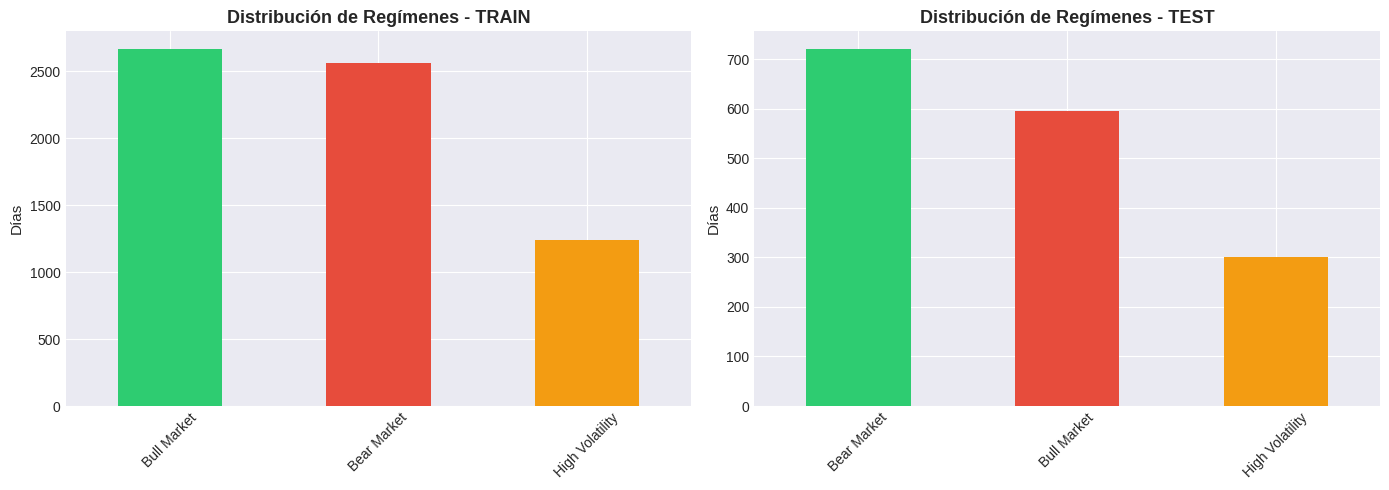

In [ ]:
print("📊 Distribución de regímenes en TRAIN:")
print(df_train['Regime_Name'].value_counts())
print(f"\n📊 Distribución de regímenes en TEST:")
print(df_test['Regime_Name'].value_counts())

# Visualizar distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_train['Regime_Name'].value_counts().plot(kind='bar', ax=axes[0],
                                              color=['#2ECC71', '#E74C3C', '#F39C12'])
axes[0].set_title('Distribución de Regímenes - TRAIN', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Días', fontsize=11)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

df_test['Regime_Name'].value_counts().plot(kind='bar', ax=axes[1],
                                             color=['#2ECC71', '#E74C3C', '#F39C12'])
axes[1].set_title('Distribución de Regímenes - TEST', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Días', fontsize=11)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('03_regime_distribution.png', dpi=150, bbox_inches='tight')
print("\n✓ Gráfico guardado: '03_regime_distribution.png'")
plt.show()

## 3.4 Entrenar Modelos por Régimen
 **Estrategia:**
 1. Entrenar 3 modelos especializados (uno por régimen)
 2. Entrenar 1 modelo baseline (sin considerar régimen)
 3. Comparar performance

 ### 3.4.1 Baseline: Modelo Genérico (sin régimen)

In [ ]:
def train_baseline_model(df_train, df_test, feature_cols):
    """
    Entrena un modelo XGBoost genérico (baseline)
    """
    print("="*70)
    print("🤖 ENTRENANDO BASELINE MODEL (sin régimen)")
    print("="*70)

    # Preparar datos
    X_train = df_train[feature_cols]
    y_train = df_train['Target']
    X_test = df_test[feature_cols]
    y_test = df_test['Target']

    # Escalar features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Entrenar XGBoost
    model = xgb.XGBClassifier(
      n_estimators=50,           # Menos árboles (era 100)
      max_depth=3,               # Árboles más shallow (era 5)
      learning_rate=0.05,        # Learning rate más bajo (era 0.1)
      min_child_weight=5,        # ⭐ NUEVO: requiere más muestras por leaf
      subsample=0.8,             # ⭐ NUEVO: usa solo 80% de datos por árbol
      colsample_bytree=0.8,      # ⭐ NUEVO: usa solo 80% de features
      gamma=1,                   # ⭐ NUEVO: penalización por split
      random_state=42,
      eval_metric='logloss'
    )

    model.fit(X_train_scaled, y_train)

    # Predicciones
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # Métricas
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    print(f"\n✓ Modelo entrenado")
    print(f"  Accuracy TRAIN: {train_acc:.3f}")
    print(f"  Accuracy TEST:  {test_acc:.3f}")

    # Classification report
    print(f"\n📊 Classification Report (TEST):")
    print(classification_report(y_test, y_pred_test,
                                target_names=['Down', 'Up']))

    return {
        'model': model,
        'scaler': scaler,
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test,
        'train_acc': train_acc,
        'test_acc': test_acc
    }

# Entrenar baseline
baseline_results = train_baseline_model(df_train, df_test, feature_columns)
# ========== FIX 1: GUARDAR PREDICCIONES BASELINE SEPARADAS ==========
# Necesitamos las predicciones del baseline en TEST para comparar después
X_test_baseline = df_test[feature_columns]
X_test_baseline_scaled = baseline_results['scaler'].transform(X_test_baseline)
baseline_predictions_test = baseline_results['model'].predict(X_test_baseline_scaled)

# Guardar en DataFrame
df_test['Prediction_Baseline'] = baseline_predictions_test

print(f"✓ Predicciones baseline guardadas en columna 'Prediction_Baseline'")

🤖 ENTRENANDO BASELINE MODEL (sin régimen)

✓ Modelo entrenado
  Accuracy TRAIN: 0.579
  Accuracy TEST:  0.560

📊 Classification Report (TEST):
              precision    recall  f1-score   support

        Down       0.53      0.12      0.19       720
          Up       0.56      0.92      0.70       896

    accuracy                           0.56      1616
   macro avg       0.55      0.52      0.45      1616
weighted avg       0.55      0.56      0.47      1616

✓ Predicciones baseline guardadas en columna 'Prediction_Baseline'


### 3.4.2 Modelos Especializados por Régimen

In [ ]:
def train_regime_specific_models(df_train, df_test, feature_cols, regimes=['Bull Market', 'Bear Market', 'High Volatility']):
    """
    Entrena un modelo XGBoost por cada régimen
    """
    print("="*70)
    print("🎯 ENTRENANDO MODELOS ESPECIALIZADOS POR RÉGIMEN")
    print("="*70)

    regime_models = {}

    for regime in regimes:
        print(f"\n{'='*70}")
        print(f"📊 RÉGIMEN: {regime}")
        print(f"{'='*70}")

        # Filtrar datos por régimen
        train_regime = df_train[df_train['Regime_Name'] == regime]
        test_regime = df_test[df_test['Regime_Name'] == regime]

        if len(train_regime) < 50:
            print(f"⚠️ Muy pocos datos de entrenamiento ({len(train_regime)}), saltando...")
            continue

        print(f"  Train samples: {len(train_regime)}")
        print(f"  Test samples:  {len(test_regime)}")

        # Preparar datos
        X_train = train_regime[feature_cols]
        y_train = train_regime['Target']
        X_test = test_regime[feature_cols]
        y_test = test_regime['Target']

        # Escalar
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Entrenar modelo
        model = xgb.XGBClassifier(
          n_estimators=50,           # Menos árboles (era 100)
          max_depth=3,               # Árboles más shallow (era 5)
          learning_rate=0.05,        # Learning rate más bajo (era 0.1)
          min_child_weight=5,        # ⭐ NUEVO: requiere más muestras por leaf
          subsample=0.8,             # ⭐ NUEVO: usa solo 80% de datos por árbol
          colsample_bytree=0.8,      # ⭐ NUEVO: usa solo 80% de features
          gamma=1,                   # ⭐ NUEVO: penalización por split
          random_state=42,
          eval_metric='logloss'
        )

        model.fit(X_train_scaled, y_train)

        # Predicciones
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)

        # Métricas
        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred_test) if len(y_test) > 0 else 0

        print(f"\n  ✓ Modelo entrenado")
        print(f"    Accuracy TRAIN: {train_acc:.3f}")
        print(f"    Accuracy TEST:  {test_acc:.3f}")

        # Guardar
        regime_models[regime] = {
            'model': model,
            'scaler': scaler,
            'y_pred_train': y_pred_train,
            'y_pred_test': y_pred_test,
            'y_test': y_test,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'train_indices': train_regime.index,
            'test_indices': test_regime.index
        }

    print("\n" + "="*70)
    print("✓ Todos los modelos por régimen entrenados")

    return regime_models

# Entrenar modelos especializados
regime_models = train_regime_specific_models(df_train, df_test, feature_columns)

🎯 ENTRENANDO MODELOS ESPECIALIZADOS POR RÉGIMEN

📊 RÉGIMEN: Bull Market
  Train samples: 2663
  Test samples:  596

  ✓ Modelo entrenado
    Accuracy TRAIN: 0.629
    Accuracy TEST:  0.557

📊 RÉGIMEN: Bear Market
  Train samples: 2560
  Test samples:  720

  ✓ Modelo entrenado
    Accuracy TRAIN: 0.648
    Accuracy TEST:  0.560

📊 RÉGIMEN: High Volatility
  Train samples: 1237
  Test samples:  300

  ✓ Modelo entrenado
    Accuracy TRAIN: 0.713
    Accuracy TEST:  0.457

✓ Todos los modelos por régimen entrenados


## 3.5 Comparación de Performance

### 3.5.1 Accuracy por Régimen: Baseline vs Especializado

📊 COMPARACIÓN: BASELINE vs MODELOS ESPECIALIZADOS


         Regime  Baseline Acc  Specialized Acc  Improvement  Test Samples
    Bull Market      0.570470         0.557047    -0.013423           596
    Bear Market      0.565278         0.559722    -0.005556           720
High Volatility      0.526667         0.456667    -0.070000           300

✓ Gráfico guardado: '03_model_comparison.png'


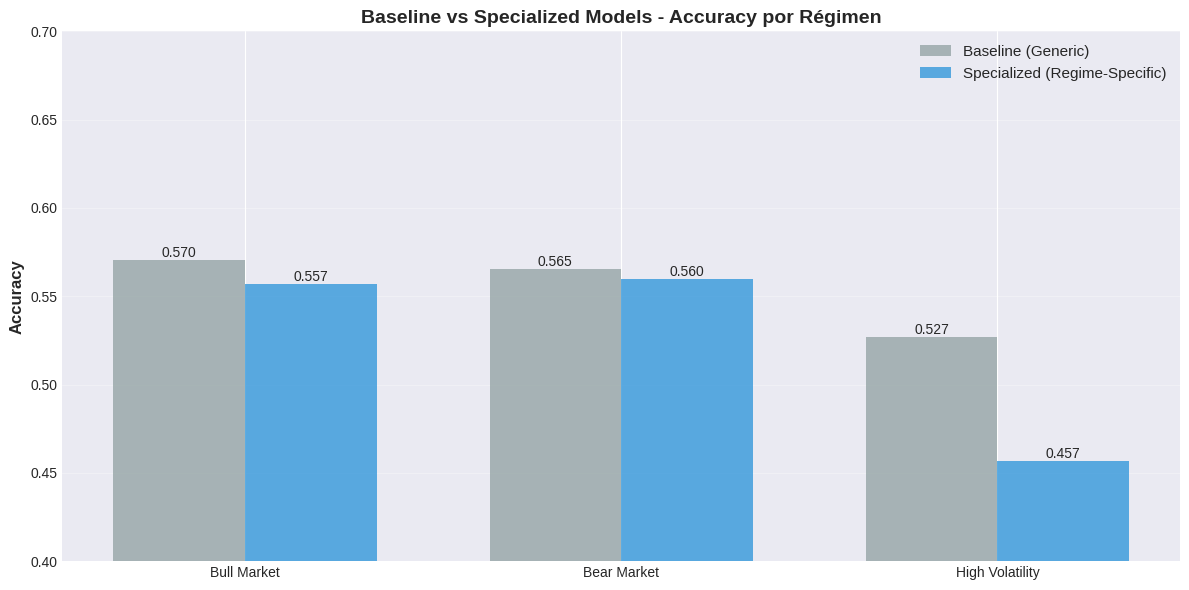


📈 RESUMEN:
  Mejora promedio: -0.030 (-3.0%)
  Mayor mejora en: Bear Market (-0.006)


In [ ]:
def compare_models_performance(baseline_results, regime_models, df_test):
    """
    Compara performance de baseline vs modelos especializados
    """
    print("="*70)
    print("📊 COMPARACIÓN: BASELINE vs MODELOS ESPECIALIZADOS")
    print("="*70)

    comparison = []

    # Baseline performance por régimen en test
    for regime in regime_models.keys():
        # Obtener índices de este régimen en test
        test_regime_mask = df_test['Regime_Name'] == regime
        test_regime_indices = df_test[test_regime_mask].index

        # Baseline predictions para este régimen
        baseline_regime_preds = baseline_results['y_pred_test'][test_regime_mask]
        baseline_regime_true = df_test.loc[test_regime_indices, 'Target']

        baseline_acc = accuracy_score(baseline_regime_true, baseline_regime_preds)

        # Specialized model accuracy
        specialized_acc = regime_models[regime]['test_acc']

        # Improvement
        improvement = specialized_acc - baseline_acc

        comparison.append({
            'Regime': regime,
            'Baseline Acc': baseline_acc,
            'Specialized Acc': specialized_acc,
            'Improvement': improvement,
            'Test Samples': len(test_regime_indices)
        })

    # Crear DataFrame
    comp_df = pd.DataFrame(comparison)

    print("\n")
    print(comp_df.to_string(index=False))

    # Visualización
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(comp_df))
    width = 0.35

    bars1 = ax.bar(x - width/2, comp_df['Baseline Acc'], width,
                   label='Baseline (Generic)', color='#95A5A6', alpha=0.8)
    bars2 = ax.bar(x + width/2, comp_df['Specialized Acc'], width,
                   label='Specialized (Regime-Specific)', color='#3498DB', alpha=0.8)

    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Baseline vs Specialized Models - Accuracy por Régimen',
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(comp_df['Regime'])
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0.4, 0.7])

    # Agregar valores sobre las barras
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig('03_model_comparison.png', dpi=150, bbox_inches='tight')
    print("\n✓ Gráfico guardado: '03_model_comparison.png'")
    plt.show()

    # Summary
    print(f"\n{'='*70}")
    print("📈 RESUMEN:")
    avg_improvement = comp_df['Improvement'].mean()
    print(f"  Mejora promedio: {avg_improvement:+.3f} ({avg_improvement*100:+.1f}%)")

    best_regime = comp_df.loc[comp_df['Improvement'].idxmax(), 'Regime']
    best_improvement = comp_df['Improvement'].max()
    print(f"  Mayor mejora en: {best_regime} ({best_improvement:+.3f})")
    print(f"{'='*70}")

    return comp_df

# Comparar modelos
comparison_df = compare_models_performance(baseline_results, regime_models, df_test)

## 3.6 Sistema Adaptativo Completo

 **Estrategia de predicción:**
 1. Detectar régimen actual
 2. Usar el modelo especializado de ese régimen
 3. Hacer predicción

In [ ]:
def create_adaptive_predictions(df_test, regime_models, feature_cols):
    """
    Crea predicciones usando sistema adaptativo
    (usa el modelo correcto según el régimen)
    """
    print("🎯 Generando predicciones adaptativas...")

    predictions = []

    for idx in df_test.index:
        # Régimen actual
        regime = df_test.loc[idx, 'Regime_Name']

        # Features
        features = df_test.loc[idx, feature_cols].values.reshape(1, -1)

        # Escalar y predecir con modelo especializado
        if regime in regime_models:
            scaler = regime_models[regime]['scaler']
            model = regime_models[regime]['model']

            features_scaled = scaler.transform(features)
            pred = model.predict(features_scaled)[0]
            pred_proba = model.predict_proba(features_scaled)[0]
        else:
            pred = 0
            pred_proba = [0.5, 0.5]

        predictions.append({
            'Date': idx,
            'Regime': regime,
            'Prediction': pred,
            'Prob_Down': pred_proba[0],
            'Prob_Up': pred_proba[1],
            'True_Label': df_test.loc[idx, 'Target']
        })

    pred_df = pd.DataFrame(predictions)
    pred_df.set_index('Date', inplace=True)

    # Accuracy del sistema adaptativo
    adaptive_acc = accuracy_score(pred_df['True_Label'], pred_df['Prediction'])

    print(f"✓ Predicciones adaptativas generadas")
    print(f"  Accuracy sistema adaptativo: {adaptive_acc:.3f}")

    return pred_df, adaptive_acc

# Generar predicciones adaptativas
adaptive_preds, adaptive_acc = create_adaptive_predictions(df_test, regime_models, feature_columns)

# Comparación final
print("\n" + "="*70)
print("🏆 COMPARACIÓN FINAL")
print("="*70)
print(f"  Baseline (genérico):        {baseline_results['test_acc']:.3f}")
print(f"  Sistema Adaptativo:         {adaptive_acc:.3f}")
print(f"  Mejora:                     {adaptive_acc - baseline_results['test_acc']:+.3f}")
print("="*70)

🎯 Generando predicciones adaptativas...
✓ Predicciones adaptativas generadas
  Accuracy sistema adaptativo: 0.540

🏆 COMPARACIÓN FINAL
  Baseline (genérico):        0.560
  Sistema Adaptativo:         0.540
  Mejora:                     -0.020


## 3.7 Feature Importance
¿Qué features son más importantes para cada régimen?


✓ Gráfico guardado: '03_feature_importance.png'


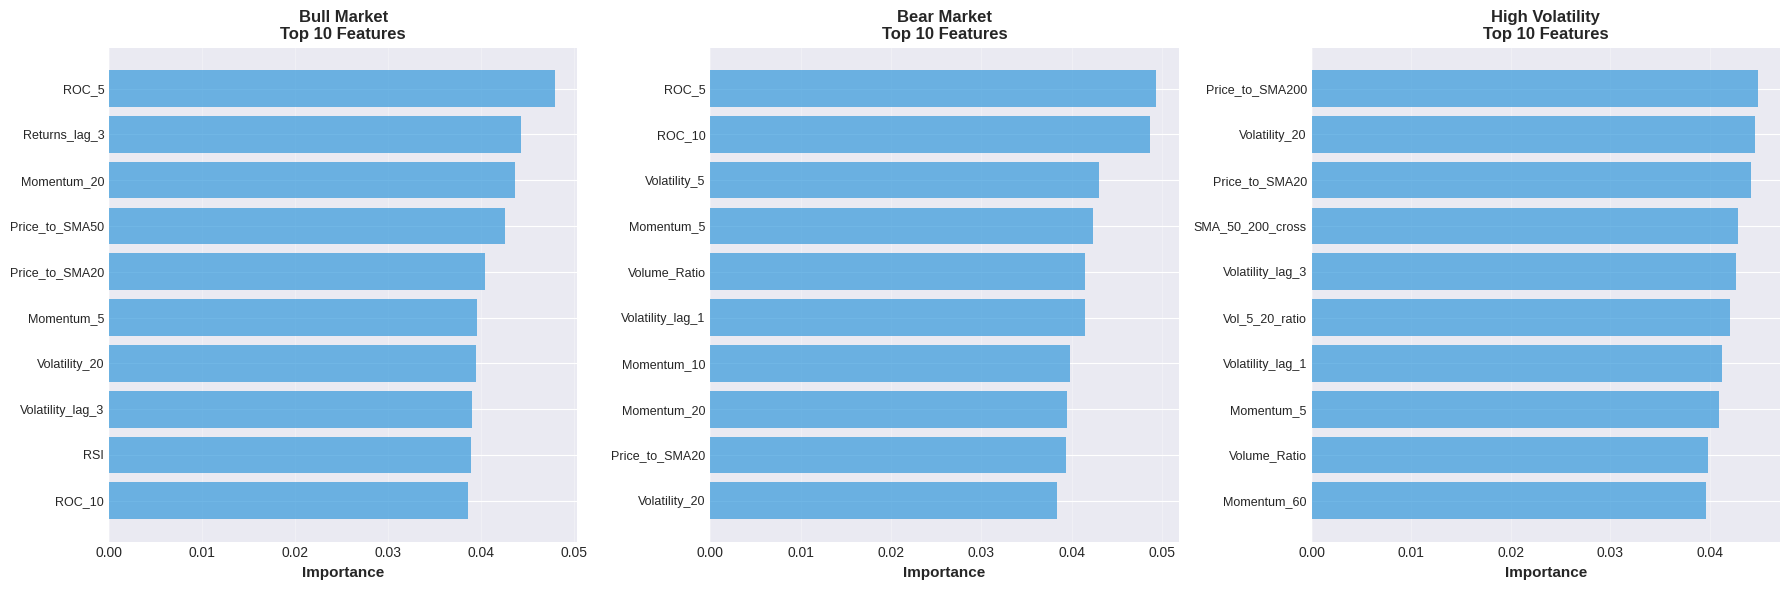

In [ ]:
def plot_feature_importance_by_regime(regime_models, feature_cols):
    """
    Visualiza feature importance para cada régimen
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for idx, (regime, results) in enumerate(regime_models.items()):
        model = results['model']

        # Get feature importance
        importance = model.feature_importances_

        # Sort
        indices = np.argsort(importance)[-10:]  # Top 10

        axes[idx].barh(range(len(indices)), importance[indices], color='#3498DB', alpha=0.7)
        axes[idx].set_yticks(range(len(indices)))
        axes[idx].set_yticklabels([feature_cols[i] for i in indices], fontsize=9)
        axes[idx].set_xlabel('Importance', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'{regime}\nTop 10 Features', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('03_feature_importance.png', dpi=150, bbox_inches='tight')
    print("✓ Gráfico guardado: '03_feature_importance.png'")
    plt.show()

# Visualizar feature importance
plot_feature_importance_by_regime(regime_models, feature_columns)

## 3.8 Guardar Predicciones y Modelos

In [ ]:
# Agregar predicciones al DataFrame completo
df_test_final = df_test.copy()
df_test_final['Prediction_Adaptive'] = adaptive_preds['Prediction']
df_test_final['Prediction_Baseline'] = df_test['Prediction_Baseline']
df_test_final['Prob_Up'] = adaptive_preds['Prob_Up']
df_test_final['Prob_Down'] = adaptive_preds['Prob_Down']

# Guardar
df_test_final.to_csv('predictions_test.csv')
print("✓ Predicciones guardadas en 'predictions_test.csv'")

# También guardar todos los datos (train + test) para backtesting, aunque solo utilizaremos los test
df_full = df_ml.copy()

# Verificación:
print("\n📊 Verificación de columnas en CSV:")
print(df_test_final[['Prediction_Baseline', 'Prediction_Adaptive']].head(10))

# Guardar modelos
import pickle

with open('regime_models.pkl', 'wb') as f:
    pickle.dump(regime_models, f)

with open('baseline_model.pkl', 'wb') as f:
    pickle.dump(baseline_results, f)

print("\n✓ Modelos guardados (.pkl)")

✓ Predicciones guardadas en 'predictions_test.csv'

📊 Verificación de columnas en CSV:
            Prediction_Baseline  Prediction_Adaptive
Date                                                
2019-07-25                    1                    1
2019-07-26                    1                    0
2019-07-29                    1                    1
2019-07-30                    1                    1
2019-07-31                    1                    1
2019-08-01                    1                    1
2019-08-02                    1                    1
2019-08-05                    1                    1
2019-08-06                    1                    1
2019-08-07                    1                    1

✓ Modelos guardados (.pkl)
